In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xmf6
from denit import gwf, gwt, plot, utils
linea = 50*chr(0x2015)

In [3]:
#
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp",
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos
    u_init = os.path.join("remix", "u_init.dat"),
    u_tilde = os.path.join("remix", "u_tilde.dat"),
    u_new = os.path.join("remix", "u_new.out"),
    #
    # Ejecutable REMIX y archivo de entrada
    remix_exe = os.path.join("remix", "bin", "interfaz_remix.exe"),
    remix_input = os.path.join("datos_interfaz_denit_2reacts"),
)
paths["command"] = f"{paths["remix_exe"]} < {paths["remix_input"]}"
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#
# Número de componentes
ncomp = 7 
#
print(linea)
print("Generating initial conditions".center(50))
comp_names, comp_conc_init, comp_ext_water = utils.initial_conditions(paths, ncomp)
print(linea)
#
xmf6.nice_print(paths, "Paths and filenames")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e-0
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.1, 1.0, 1.0 
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Spatial discretization")
#
# Parámetros físicos.
phys = dict(
    perioddata = [(dt, 1, 1.0)], #PERLEN, NSTP, TSMULT
    components = comp_names, # Components names
    specific_discharge = 0.2,  # Specific discharge ($cm s^{-1}$)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    source_concentration = comp_ext_water,  # Source concentration (unitless)
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    initial_concentration = comp_conc_init, # Initial concentration (unitless)
    longitudinal_dispersivity = 1.0,
)
xmf6.nice_print(phys, "Physical parameters")

――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
-> File remix\u_init.dat already exist
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
    mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
    mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
  flow_name = flow
    flow_ws = mf6_gwf_gwt_comp
  tran_name = transport
    tran_ws = mf6_gwf_gwt_comp
     u_init = remix\u_init.dat
    u_tilde = remix\u_tilde.dat
      u_new = remix\u_new.out
  remix_exe = remix\bin\interfaz_remix.exe
remix_input = datos_interfaz_denit_2reacts
    command = remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 1.0
         top = 1.0
        botm = 0.0
――――――――――――――――――――――

Physi

In [4]:
U = [0 for i in range(0,ncomp)]

for t in range(1, 11):
    print(linea)
    print(f"Time step = {t}".center(50))
    print(linea)

    for m in range(0, ncomp):
        #
        # - ACTUALIZACION DEL FLUJO CON GWF ---
        #
        # --- Construcción de la simulación de flujo
        o_sim_f = gwf.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación ---
        print("- GWF", end = " ")
        o_sim_f.run_simulation(silent=True)
        #
        # - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
        #
        # --- Construcción de la simulación de transporte
        o_sim_t = gwt.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación de transporte ---
        print(f"- GWT: C{m+1}", end= " | ")
        o_sim_t.run_simulation(silent=True)
        #
        # --- Obtenemos la concentración calculada por GWT
        U[m] = utils.get_conc(o_sim_t)
    #
    # --- Guardamos concentraciones en "u_tilde.dat"
    print("\n-> Writting: u_tilde.dat")
    with open(paths["u_tilde"], "w") as f:
        for a in U:
            f.writelines(" ".join([c for c in a.astype(str)]))
            f.write("\n")
    #
    # ---- Ejecutamos REMIX usando las nuevas concentraciones
    print(f"-> Executing: {paths["command"]}\n")
    ret = os.system(paths["command"])
    print(f"\n-> Error code: {ret}")
    #
    # --- Leemos las concentraciones de las componentes calculadas por REMIX
    print(f"-> Reading: {paths["u_new"]}")
    with open(paths["u_new"], "r") as f:
        lines = f.readlines()
    #
    # Actualizamos las concentraciones para GWT
    key_string = "Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):"
    iccn = utils.find_index(lines, key_string, 2)
    comp_conc_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp]]
    phys["initial_concentration"] = comp_conc_new


――――――――――――――――――――――――――――――――――――――――――――――――――
                  Time step = 1                   
――――――――――――――――――――――――――――――――――――――――――――――――――
- GWF - GWT: C1 | - GWF - GWT: C2 | - GWF - GWT: C3 | - GWF - GWT: C4 | - GWF - GWT: C5 | - GWF - GWT: C6 | - GWF - GWT: C7 | 
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
                  Time step = 2                   
――――――――――――――――――――――――――――――――――――――――――――――――――
- GWF - GWT: C1 | - GWF - GWT: C2 | - GWF - GWT: C3 | - GWF - GWT: C4 | - GWF - GWT: C5 | - GWF - GWT: C6 | - GWF - GWT: C7 | 
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
                  Time step = 3                   
――――――――――――――――――――――――――――――――――――――――――――――

In [5]:
print(comp_conc_new)

[array([2.98839e-05, 3.21026e-05, 3.40287e-05, 3.56808e-05, 3.70758e-05,
       3.82283e-05, 3.91495e-05, 3.98462e-05, 4.03194e-05, 4.05631e-05]), array([0.00050864, 0.00046551, 0.00042458, 0.00038649, 0.00035189,
       0.00032141, 0.00029571, 0.00027543, 0.00026121, 0.00025375]), array([0.00051228, 0.0004695 , 0.0004289 , 0.00039112, 0.00035682,
       0.0003266 , 0.00030113, 0.00028102, 0.00026693, 0.00025953]), array([7.82948e-07, 8.19050e-07, 8.46202e-07, 8.66459e-07, 8.81435e-07,
       8.92374e-07, 9.00206e-07, 9.05607e-07, 9.09025e-07, 9.10710e-07]), array([0.00098961, 0.00090158, 0.00081821, 0.00074078, 0.00067054,
       0.00060877, 0.00055672, 0.00051567, 0.00048693, 0.00047184]), array([0.00079891, 0.00082097, 0.00084172, 0.00086089, 0.0008782 ,
       0.00089336, 0.00090609, 0.00091611, 0.00092312, 0.00092679]), array([9.86891e-05, 8.57730e-05, 7.36979e-05, 6.26068e-05, 5.26429e-05,
       4.39493e-05, 3.66718e-05, 3.09609e-05, 2.69760e-05, 2.48892e-05])]


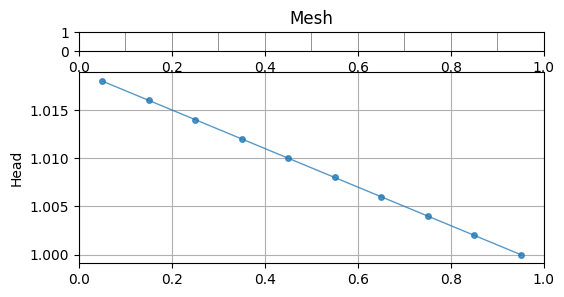

In [6]:
o_gwf, head, x, y, z = utils.get_head(o_sim_f)
plot.show_f(o_gwf, head, x, y, z)

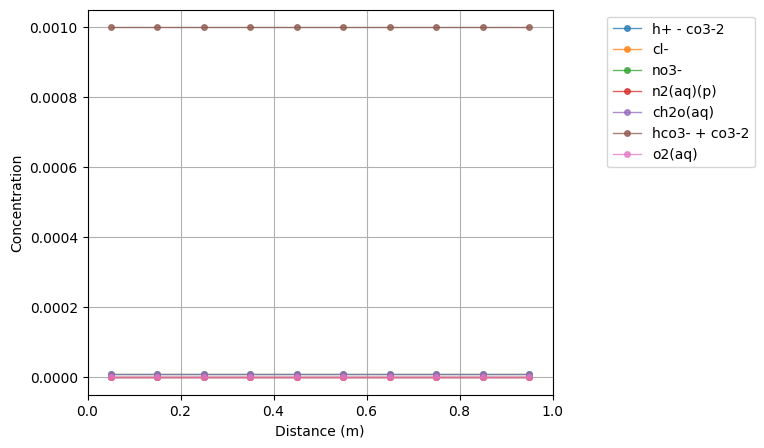

In [7]:
plot.show_t(comp_conc_init, comp_names, x, y, z)

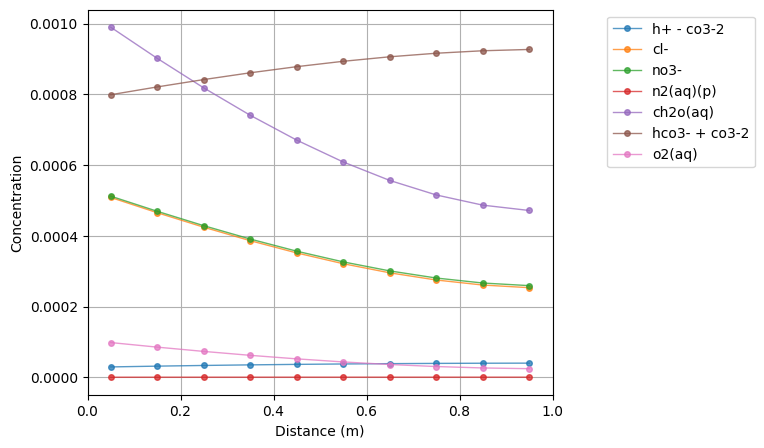

In [8]:
plot.show_t(comp_conc_new, comp_names, x, y, z)